# 优化算法实验 🌿

## 实验背景

本实验将以**植物病害检测**为背景，构建一个二分类神经网络，根据叶片的两项特征（如颜色指数和纹理指数）判断植物是否患病（0 = 健康，1 = 患病）。

优化算法的选择直接影响模型的训练速度和最终精度。本实验将对比以下算法：

- **梯度下降（Gradient Descent）**：最基础的优化方法
- **小批量梯度下降（Mini-Batch GD）**：在全批量与随机梯度下降之间取得平衡
- **动量法（Momentum）**：引入历史梯度信息加速收敛
- **Adam**：结合动量与自适应学习率的强力优化器
- **学习率衰减（LR Decay）**：在训练后期降低学习率，提升稳定性

## 学习目标 🎯

完成本实验后，你将能够：

- 💡 理解并实现梯度下降、动量法和 Adam 优化器
- 🔢 构建小批量训练流程
- 📉 实现指数学习率衰减与分段学习率调度
- 📊 直观比较不同优化算法的收敛行为

## 目录

- [1 - 导入包](#1)
- [2 - 梯度下降](#2)
    - [练习 1 - update_parameters_with_gd](#ex-1)
- [3 - 小批量梯度下降](#3)
    - [练习 2 - random_mini_batches](#ex-2)
- [4 - 动量法](#4)
    - [练习 3 - initialize_velocity](#ex-3)
    - [练习 4 - update_parameters_with_momentum](#ex-4)
- [5 - Adam 优化器](#5)
    - [练习 5 - initialize_adam](#ex-5)
    - [练习 6 - update_parameters_with_adam](#ex-6)
- [6 - 不同优化方法的模型比较](#6)
- [7 - 学习率衰减与调度](#7)
    - [练习 7 - update_lr](#ex-7)
    - [练习 8 - schedule_lr_decay](#ex-8)
- [8 - 总结](#8)

<a name='1'></a>
## 1 - 导入包 📦

运行下方代码块，加载本实验所需的全部依赖。

In [72]:
### v1.0

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import math
import sklearn
import sklearn.datasets

from opt_utils_v1a import load_params_and_grads, initialize_parameters, forward_propagation, backward_propagation
from opt_utils_v1a import compute_cost, predict, predict_dec, plot_decision_boundary, load_dataset
from testCases import *
from public_tests import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [74]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = [
    'PingFang SC',        # macOS
    'Hiragino Sans GB',   # macOS（备用）
    'Microsoft YaHei',    # Windows
    'SimHei',             # Windows（备用）
    'Noto Sans CJK SC',   # Linux / 通用
    'Arial Unicode MS'    # 兜底
]

plt.rcParams['axes.unicode_minus'] = False

<a name='2'></a>
## 2 - 梯度下降（Gradient Descent）

梯度下降是最基础的优化方法。每次迭代时，模型沿着损失函数梯度的反方向更新参数：

$$W^{[l]} = W^{[l]} - \alpha \cdot dW^{[l]}$$
$$b^{[l]} = b^{[l]} - \alpha \cdot db^{[l]}$$

其中 $\alpha$ 为学习率，$l$ 为层序号。

> 💡 **提示**：网络共有 $L$ 层，需要对每一层的 $W$ 和 $b$ 同步更新。

<a name='ex-1'></a>
### 练习 1 - update_parameters_with_gd

**任务**：实现一步梯度下降参数更新。

**输入**：
- `parameters`：字典，包含 `"W1"`, `"b1"`, ..., `"WL"`, `"bL"`
- `grads`：字典，包含 `"dW1"`, `"db1"`, ..., `"dWL"`, `"dbL"`
- `learning_rate`：学习率 $\alpha$

**提示**：
- 层数 $L$ 可通过 `len(parameters) // 2` 获得
- 对每层 $l = 1, \ldots, L$，执行 $W^{[l]} \leftarrow W^{[l]} - \alpha \cdot dW^{[l]}$，$b$ 同理

In [75]:
# GRADED FUNCTION: update_parameters_with_gd

def update_parameters_with_gd(parameters, grads, learning_rate):
    """
    使用梯度下降更新参数。

    参数：
    parameters    -- 字典，包含各层参数 "W1","b1",...,"WL","bL"
    grads         -- 字典，包含各层梯度 "dW1","db1",...,"dWL","dbL"
    learning_rate -- 学习率 alpha

    返回：
    parameters -- 更新后的参数字典
    """
    L = len(parameters) // 2  # 神经网络层数

    for l in range(1, L + 1):
        ### START CODE HERE ###
        ### END CODE HERE ###

    return parameters

In [76]:
parameters, grads, learning_rate = update_parameters_with_gd_test_case()
learning_rate = 0.01

params_updated = update_parameters_with_gd(parameters, grads, learning_rate)
print("W1 =\n" + str(params_updated["W1"]))
print("b1 =\n" + str(params_updated["b1"]))
print("W2 =\n" + str(params_updated["W2"]))
print("b2 =\n" + str(params_updated["b2"]))
update_parameters_with_gd_test(update_parameters_with_gd)

W1 =
[[ 1.63312395 -0.61217855 -0.5339999 ]
 [-1.06196243  0.85396039 -2.3105546 ]]
b1 =
[[ 1.73978682]
 [-0.77021546]]
W2 =
[[ 0.32587637 -0.24814147]
 [ 1.47146563 -2.05746183]
 [-0.32772076 -0.37713775]]
b2 =
[[ 1.13773698]
 [-1.09301954]
 [-0.16397615]]
All tests passed


<a name='3'></a>
## 3 - 小批量梯度下降（Mini-Batch Gradient Descent）

**全批量梯度下降**每次使用全部样本计算梯度，计算量大且收敛慢。  
**随机梯度下降（SGD）**每次只用 1 个样本，速度快但噪声大。  
**小批量梯度下降**是两者的折中：每次随机抽取大小为 `mini_batch_size` 的子集更新参数。

构建小批量的步骤：
1. **随机打乱（Shuffle）**：对训练集 $(X, Y)$ 进行同步随机置换
2. **分割（Partition）**：将打乱后的数据按 `mini_batch_size` 切分（最后一个批次可能更小）

<a name='ex-2'></a>
### 练习 2 - random_mini_batches

**任务**：将训练集随机划分为若干小批量。

**提示**：
- 使用 `np.random.permutation` 生成随机排列索引
- 完整批次数量：`num_complete_minibatches = math.floor(m / mini_batch_size)`
- 最后一个不完整批次（若存在）需单独处理
- 切记 $X$ 和 $Y$ 必须使用**相同**的索引打乱

In [77]:
# GRADED FUNCTION: random_mini_batches

def random_mini_batches(X, Y, mini_batch_size=64, seed=0):
    """
    从训练集 (X, Y) 中随机构建小批量列表。

    参数：
    X               -- 输入数据，形状 (输入维度, 样本数)
    Y               -- 标签，形状 (1, 样本数)
    mini_batch_size -- 每个小批量的样本数
    seed            -- 随机种子，保证可复现性

    返回：
    mini_batches -- 列表，每个元素为 (mini_batch_X, mini_batch_Y)
    """
    np.random.seed(seed)
    m = X.shape[1]       # 训练样本总数
    mini_batches = []

    # 步骤 1：随机打乱训练集
    ### START CODE HERE ###
    ### END CODE HERE ###

    inc = mini_batch_size

    # 步骤 2：按 mini_batch_size 分割（完整批次）
    num_complete_minibatches = math.floor(m / mini_batch_size)
    for k in range(num_complete_minibatches):
        ### START CODE HERE ###
        ### END CODE HERE ###
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    # 步骤 3：处理最后一个不完整批次（若存在）
    if m % mini_batch_size != 0:
        ### START CODE HERE ###
        ### END CODE HERE ###
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    return mini_batches

In [78]:
np.random.seed(1)
mini_batch_size = 2
X_test = np.random.randn(5, 7)
Y_test = np.random.randn(1, 7) < 0.5

mini_batches = random_mini_batches(X_test, Y_test, mini_batch_size)
n_batches = len(mini_batches)

print("总小批量数量：", n_batches)
for i, mb in enumerate(mini_batches):
    print(f"小批量 {i+1} - X 形状：{mb[0].shape}，Y 形状：{mb[1].shape}")

random_mini_batches_test(random_mini_batches)

总小批量数量： 4
小批量 1 - X 形状：(5, 2)，Y 形状：(1, 2)
小批量 2 - X 形状：(5, 2)，Y 形状：(1, 2)
小批量 3 - X 形状：(5, 2)，Y 形状：(1, 2)
小批量 4 - X 形状：(5, 1)，Y 形状：(1, 1)
 All tests passed.


<a name='4'></a>
## 4 - 动量法（Momentum）

动量法通过引入**指数加权移动平均**来累积历史梯度信息，从而减少震荡、加速收敛。

**初始化**：
$$v_{dW^{[l]}} = \mathbf{0}, \quad v_{db^{[l]}} = \mathbf{0}$$

**每次迭代更新**：
$$v_{dW^{[l]}} = \beta \, v_{dW^{[l]}} + (1 - \beta) \, dW^{[l]}$$
$$W^{[l]} = W^{[l]} - \alpha \, v_{dW^{[l]}}$$

（$b$ 的更新同理）

其中 $\beta$（动量超参数，通常取 0.9）决定了历史梯度的权重。

<a name='ex-3'></a>
### 练习 3 - initialize_velocity

**任务**：将动量速度 $v$ 初始化为全零字典。

**提示**：
- 字典 `v` 的键为 `"dW1"`, `"db1"`, ..., `"dWL"`, `"dbL"`
- 每个值的形状与对应参数相同，初始值为 **全零矩阵**

In [79]:
# GRADED FUNCTION: initialize_velocity

def initialize_velocity(parameters):
    """
    初始化动量速度字典 v，所有值为零矩阵。

    参数：
    parameters -- 字典，包含 "W1","b1",...,"WL","bL"

    返回：
    v -- 字典，包含 "dW1","db1",...,"dWL","dbL"，形状与对应参数相同，值为 0
    """
    L = len(parameters) // 2  # 网络层数
    v = {}

    for l in range(1, L + 1):
        ### START CODE HERE ###
        ### END CODE HERE ###

    return v

In [80]:
parameters = initialize_velocity_test_case()
v = initialize_velocity(parameters)
print("v['dW1'] =\n" + str(v["dW1"]))
print("v['db1'] =\n" + str(v["db1"]))
print("v['dW2'] =\n" + str(v["dW2"]))
print("v['db2'] =\n" + str(v["db2"]))
initialize_velocity_test(initialize_velocity)

v['dW1'] =
[[0. 0.]
 [0. 0.]
 [0. 0.]]
v['db1'] =
[[0.]
 [0.]
 [0.]]
v['dW2'] =
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
v['db2'] =
[[0.]
 [0.]
 [0.]]
 All tests passed.


<a name='ex-4'></a>
### 练习 4 - update_parameters_with_momentum

**任务**：实现带动量的参数更新。

对每层 $l = 1, \ldots, L$：

$$v_{dW^{[l]}} = \beta \, v_{dW^{[l]}} + (1 - \beta) \, dW^{[l]}$$
$$W^{[l]} = W^{[l]} - \alpha \, v_{dW^{[l]}}$$

$$v_{db^{[l]}} = \beta \, v_{db^{[l]}} + (1 - \beta) \, db^{[l]}$$
$$b^{[l]} = b^{[l]} - \alpha \, v_{db^{[l]}}$$

In [81]:
# GRADED FUNCTION: update_parameters_with_momentum

def update_parameters_with_momentum(parameters, grads, v, beta, learning_rate):
    """
    使用动量法更新参数。

    参数：
    parameters    -- 字典，包含各层参数
    grads         -- 字典，包含各层梯度
    v             -- 字典，动量速度
    beta          -- 动量超参数，控制历史梯度权重
    learning_rate -- 学习率 alpha

    返回：
    parameters -- 更新后的参数字典
    v          -- 更新后的速度字典
    """
    L = len(parameters) // 2

    for l in range(1, L + 1):
        ### START CODE HERE ###
        # 计算速度
        # 更新参数
        ### END CODE HERE ###

    return parameters, v

In [82]:
parameters, grads, v = update_parameters_with_momentum_test_case()

parameters, v = update_parameters_with_momentum(parameters, grads, v, beta=0.9, learning_rate=0.01)
print("W1 =\n" + str(parameters["W1"]))
print("b1 =\n" + str(parameters["b1"]))
print("W2 =\n" + str(parameters["W2"]))
print("b2 =\n" + str(parameters["b2"]))
print("v['dW1'] =\n" + str(v["dW1"]))
print("v['db1'] =\n" + str(v["db1"]))
update_parameters_with_momentum_test(update_parameters_with_momentum)

W1 =
[[ 1.62522322 -0.61179863 -0.52875457]
 [-1.071868    0.86426291 -2.30244029]]
b1 =
[[ 1.74430927]
 [-0.76210776]]
W2 =
[[ 0.31972282 -0.24924749]
 [ 1.46304371 -2.05987282]
 [-0.32294756 -0.38336269]]
b2 =
[[ 1.1341662 ]
 [-1.09920409]
 [-0.171583  ]]
v['dW1'] =
[[-0.08778584  0.00422137  0.05828152]
 [-0.11006192  0.11447237  0.09015907]]
v['db1'] =
[[0.05024943]
 [0.09008559]]
 All tests passed.


<a name='5'></a>
## 5 - Adam 优化器

Adam（Adaptive Moment Estimation）结合了**动量法**（一阶矩）和 **RMSProp**（二阶矩），是目前最常用的优化算法之一。

**初始化**：$v_{dW} = 0,\ s_{dW} = 0$（各层均初始化为 0）

**每次迭代更新**（对层 $l$）：

$$v_{dW^{[l]}} = \beta_1 \, v_{dW^{[l]}} + (1 - \beta_1) \, dW^{[l]}$$
$$s_{dW^{[l]}} = \beta_2 \, s_{dW^{[l]}} + (1 - \beta_2) \, (dW^{[l]})^2$$

**偏差修正**：

$$v^{\text{corrected}}_{dW^{[l]}} = \frac{v_{dW^{[l]}}}{1 - \beta_1^t}, \quad s^{\text{corrected}}_{dW^{[l]}} = \frac{s_{dW^{[l]}}}{1 - \beta_2^t}$$

**参数更新**：

$$W^{[l]} = W^{[l]} - \alpha \cdot \frac{v^{\text{corrected}}_{dW^{[l]}}}{\sqrt{s^{\text{corrected}}_{dW^{[l]}}} + \varepsilon}$$

常用超参数：$\beta_1 = 0.9$，$\beta_2 = 0.999$，$\varepsilon = 10^{-8}$。

<a name='ex-5'></a>
### 练习 5 - initialize_adam

**任务**：将 Adam 的一阶矩 $v$ 和二阶矩 $s$ 初始化为全零字典。

**提示**：结构与 `initialize_velocity` 完全相同，只需同时初始化 `v` 和 `s`。

In [83]:
# GRADED FUNCTION: initialize_adam

def initialize_adam(parameters):
    """
    初始化 Adam 优化器所需的一阶矩 v 和二阶矩 s，均为全零。

    参数：
    parameters -- 字典，包含各层参数 "W1","b1",...,"WL","bL"

    返回：
    v -- 字典，一阶矩（指数加权梯度），初始值为 0
    s -- 字典，二阶矩（指数加权梯度平方），初始值为 0
    """
    L = len(parameters) // 2
    v = {}
    s = {}

    for l in range(1, L + 1):
        ### START CODE HERE ###
        ### END CODE HERE ###

    return v, s

In [84]:
parameters = initialize_adam_test_case()
v, s = initialize_adam(parameters)
print("v['dW1'] =\n" + str(v["dW1"]))
print("v['db1'] =\n" + str(v["db1"]))
print("v['dW2'] =\n" + str(v["dW2"]))
print("v['db2'] =\n" + str(v["db2"]))
print("s['dW1'] =\n" + str(s["dW1"]))
print("s['db1'] =\n" + str(s["db1"]))
initialize_adam_test(initialize_adam)

v['dW1'] =
[[0. 0. 0.]
 [0. 0. 0.]]
v['db1'] =
[[0.]
 [0.]]
v['dW2'] =
[[0. 0.]
 [0. 0.]
 [0. 0.]]
v['db2'] =
[[0.]
 [0.]
 [0.]]
s['dW1'] =
[[0. 0. 0.]
 [0. 0. 0.]]
s['db1'] =
[[0.]
 [0.]]
 All tests passed.


<a name='ex-6'></a>
### 练习 6 - update_parameters_with_adam

**任务**：实现 Adam 的完整参数更新步骤。

对每层 $l = 1, \ldots, L$，按以下顺序执行：
1. 更新一阶矩 $v$（带 $\beta_1$）
2. 更新二阶矩 $s$（带 $\beta_2$）
3. 计算偏差修正的 $v^{\text{corrected}}$ 和 $s^{\text{corrected}}$
4. 更新参数（使用修正后的矩）

**注意**：函数返回 `(parameters, v, s, v_corrected, s_corrected)` 共 5 个值。

In [85]:
# GRADED FUNCTION: update_parameters_with_adam

def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate=0.01,
                                 beta1=0.9, beta2=0.999, epsilon=1e-8):
    """
    使用 Adam 优化器更新参数。

    参数：
    parameters    -- 字典，包含各层参数
    grads         -- 字典，包含各层梯度
    v             -- Adam 一阶矩字典
    s             -- Adam 二阶矩字典
    t             -- 当前迭代轮次（用于偏差修正）
    learning_rate -- 学习率 alpha（默认 0.01）
    beta1         -- 一阶矩衰减系数（默认 0.9）
    beta2         -- 二阶矩衰减系数（默认 0.999）
    epsilon       -- 防止除零的小常数（默认 1e-8）

    返回：
    parameters  -- 更新后的参数字典
    v           -- 更新后的一阶矩字典
    s           -- 更新后的二阶矩字典
    v_corrected -- 偏差修正后的一阶矩字典
    s_corrected -- 偏差修正后的二阶矩字典
    """
    L = len(parameters) // 2
    v_corrected = {}
    s_corrected = {}

    for l in range(1, L + 1):
        ### START CODE HERE ###
        # 更新一阶矩（动量项）
        # 偏差修正一阶矩
        # 更新二阶矩（RMSProp 项）
        # 偏差修正二阶矩
        # Adam 参数更新
        ### END CODE HERE ###

    return parameters, v, s, v_corrected, s_corrected

In [86]:
parametersi, grads, vi, si, t, learning_rate, beta1, beta2, epsilon = update_parameters_with_adam_test_case()

parameters, v, s, vc, sc = update_parameters_with_adam(parametersi, grads, vi, si, t, learning_rate, beta1, beta2, epsilon)
print(f"W1 =\n{parameters['W1']}")
print(f"b1 =\n{parameters['b1']}")
print(f"v['dW1'] =\n{v['dW1']}")
print(f"v_corrected['dW1'] =\n{vc['dW1']}")
print(f"s['dW1'] =\n{s['dW1']}")
update_parameters_with_adam_test(update_parameters_with_adam)

W1 =
[[ 1.63937725 -0.62327448 -0.54308727]
 [-1.0578897   0.85032154 -2.31657668]]
b1 =
[[ 1.72995096]
 [-0.7762447 ]]
v['dW1'] =
[[-0.17557168  0.00844275  0.11656304]
 [-0.22012384  0.22894474  0.18031814]]
v_corrected['dW1'] =
[[-0.48769912  0.02345208  0.32378623]
 [-0.6114551   0.63595762  0.50088373]]
s['dW1'] =
[[0.08631117 0.00019958 0.03804344]
 [0.13567261 0.14676395 0.09104097]]
All tests passed


<a name='6'></a>
## 6 - 不同优化方法的模型比较

下面提供了完整的 `model()` 函数（无需修改），用于在植物病害检测数据集上训练神经网络，支持三种优化器：`"gd"`、`"momentum"`、`"adam"`。

In [87]:
def model(X, Y, layers_dims, optimizer, learning_rate=0.0007, mini_batch_size=64,
          beta=0.9, beta1=0.9, beta2=0.999, epsilon=1e-8, num_epochs=10000,
          print_cost=True, decay=None, decay_rate=1):
    """
    可配置优化器的 L 层神经网络训练函数。

    参数：
    X, Y           -- 训练数据与标签
    layers_dims    -- 各层维度列表
    optimizer      -- 优化器类型："gd" / "momentum" / "adam"
    learning_rate  -- 初始学习率
    mini_batch_size-- 小批量大小
    beta           -- 动量法的 beta 超参数
    beta1, beta2   -- Adam 的 beta1, beta2
    epsilon        -- Adam 的 epsilon
    num_epochs     -- 训练轮次
    print_cost     -- 是否每 1000 轮打印损失
    decay          -- 学习率衰减函数（可选）
    decay_rate     -- 衰减率

    返回：
    parameters -- 训练后的参数字典
    """
    L = len(layers_dims)
    costs = []
    t = 0
    seed = 10
    m = X.shape[1]
    lr_rates = []
    learning_rate0 = learning_rate

    parameters = initialize_parameters(layers_dims)

    if optimizer == "gd":
        pass
    elif optimizer == "momentum":
        v = initialize_velocity(parameters)
    elif optimizer == "adam":
        v, s = initialize_adam(parameters)

    for i in range(num_epochs):
        seed += 1
        minibatches = random_mini_batches(X, Y, mini_batch_size, seed)
        cost_total = 0

        for minibatch in minibatches:
            (minibatch_X, minibatch_Y) = minibatch
            a3, caches = forward_propagation(minibatch_X, parameters)
            cost_total += compute_cost(a3, minibatch_Y)
            grads = backward_propagation(minibatch_X, minibatch_Y, caches)

            if optimizer == "gd":
                parameters = update_parameters_with_gd(parameters, grads, learning_rate)
            elif optimizer == "momentum":
                parameters, v = update_parameters_with_momentum(parameters, grads, v, beta, learning_rate)
            elif optimizer == "adam":
                t += 1
                parameters, v, s, _, _ = update_parameters_with_adam(
                    parameters, grads, v, s, t, learning_rate, beta1, beta2, epsilon)

        cost_avg = cost_total / m
        if decay:
            learning_rate = decay(learning_rate0, i, decay_rate)

        if print_cost and i % 1000 == 0:
            print(f"第 {i} 轮损失：{cost_avg:.6f}")
            costs.append(cost_avg)
            if decay:
                lr_rates.append(learning_rate)

    plt.figure()
    plt.plot(costs)
    plt.ylabel('损失值')
    plt.xlabel('迭代轮次（每 1000 轮）')
    plt.title(f'优化器：{optimizer}，学习率：{learning_rate0}')
    plt.show()

    return parameters

### 6.1 - 加载数据集

下面加载模拟的叶片特征数据集（月牙形分布），可视化两类样本（0=健康，1=患病）。

训练集形状 - X: (2, 300)   Y: (1, 300)


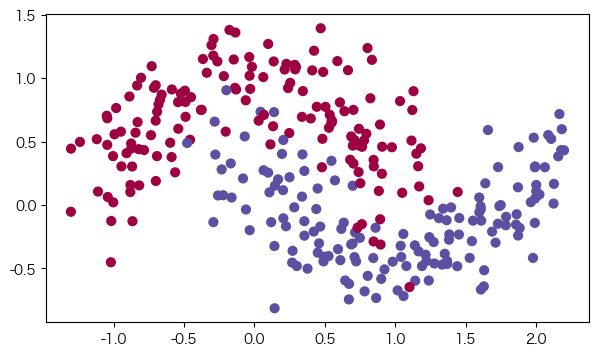

In [88]:
train_X, train_Y = load_dataset()
print("训练集形状 - X:", train_X.shape, "  Y:", train_Y.shape)

### 6.2 - 梯度下降训练

第 0 轮损失：0.702405
第 1000 轮损失：0.668101
第 2000 轮损失：0.635288
第 3000 轮损失：0.600491
第 4000 轮损失：0.573367
第 5000 轮损失：0.551977
第 6000 轮损失：0.532370
第 7000 轮损失：0.514007
第 8000 轮损失：0.496472
第 9000 轮损失：0.468014


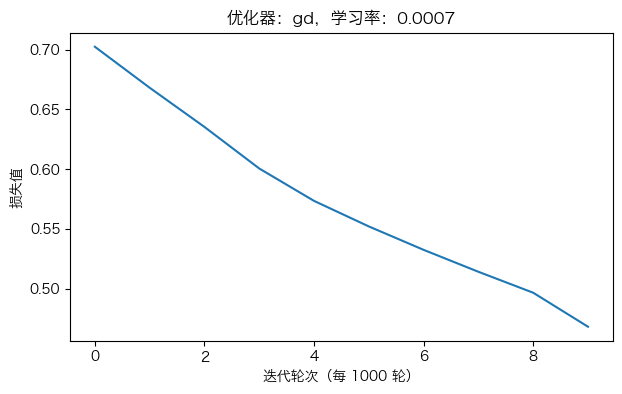


训练集准确率：
准确率：0.7966666666666666

测试集决策边界：


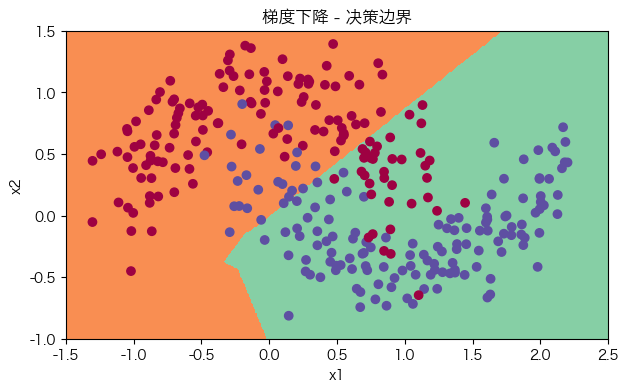

In [89]:
# 使用梯度下降优化器训练（小批量）
layers_dims = [train_X.shape[0], 5, 2, 1]
parameters = model(train_X, train_Y, layers_dims, optimizer="gd",
                   learning_rate=0.0007, mini_batch_size=64, num_epochs=10000, print_cost=True)
print("\n训练集准确率：")
predictions_train = predict(train_X, train_Y, parameters)
print("\n测试集决策边界：")
plt.title("梯度下降 - 决策边界")
axes = plt.gca()
axes.set_xlim([-1.5, 2.5])
axes.set_ylim([-1, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y[0,:])

### 6.3 - 动量法训练

第 0 轮损失：0.702413
第 1000 轮损失：0.668167
第 2000 轮损失：0.635388
第 3000 轮损失：0.600591
第 4000 轮损失：0.573444
第 5000 轮损失：0.552058
第 6000 轮损失：0.532458
第 7000 轮损失：0.514101
第 8000 轮损失：0.496652
第 9000 轮损失：0.468160


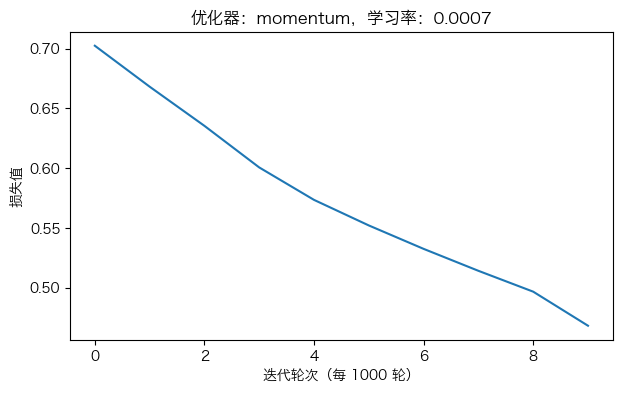


训练集准确率：
准确率：0.7966666666666666

决策边界：


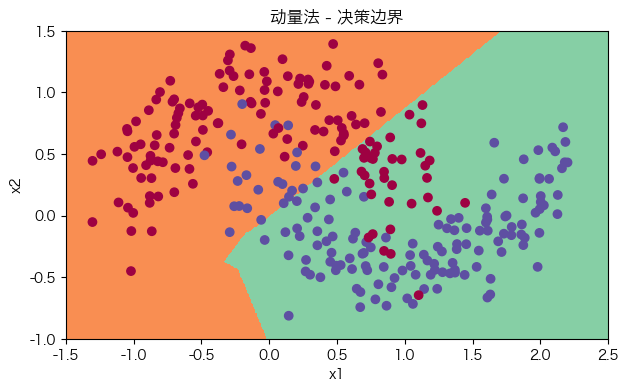

In [90]:
parameters = model(train_X, train_Y, layers_dims, optimizer="momentum",
                   learning_rate=0.0007, mini_batch_size=64, beta=0.9, num_epochs=10000, print_cost=True)
print("\n训练集准确率：")
predictions_train = predict(train_X, train_Y, parameters)
print("\n决策边界：")
plt.title("动量法 - 决策边界")
axes = plt.gca()
axes.set_xlim([-1.5, 2.5])
axes.set_ylim([-1, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y[0,:])

### 6.4 - Adam 训练

第 0 轮损失：0.702166
第 1000 轮损失：0.167845
第 2000 轮损失：0.141316
第 3000 轮损失：0.138788
第 4000 轮损失：0.136066
第 5000 轮损失：0.134240
第 6000 轮损失：0.131127
第 7000 轮损失：0.130216
第 8000 轮损失：0.129623
第 9000 轮损失：0.129118


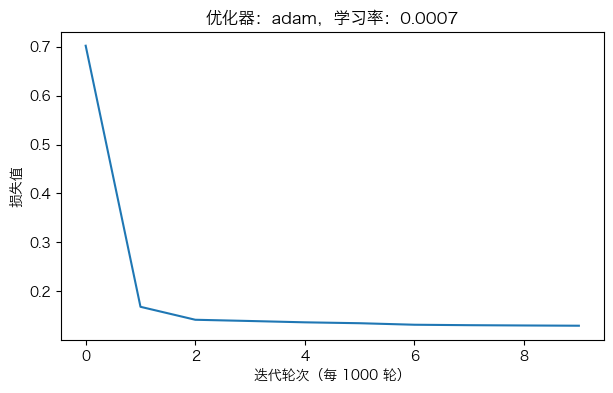


训练集准确率：
准确率：0.94

决策边界：


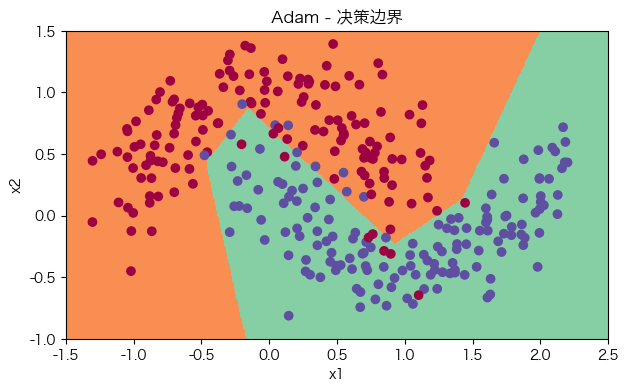

In [91]:
parameters = model(train_X, train_Y, layers_dims, optimizer="adam",
                   learning_rate=0.0007, mini_batch_size=64,
                   beta1=0.9, beta2=0.999, epsilon=1e-8, num_epochs=10000, print_cost=True)
print("\n训练集准确率：")
predictions_train = predict(train_X, train_Y, parameters)
print("\n决策边界：")
plt.title("Adam - 决策边界")
axes = plt.gca()
axes.set_xlim([-1.5, 2.5])
axes.set_ylim([-1, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y[0,:])

### 6.5 - 小结

| 优化器 | 收敛速度 | 稳定性 |
|--------|--------|--------|
| 小批量梯度下降 | 慢 | 震荡明显 |
| 动量法 | 较快 | 较平稳 |
| Adam | **最快** | **最稳定** |

> 💡 Adam 在大多数深度学习任务中表现优秀，但某些场景下动量法已足够好。

<a name='7'></a>
## 7 - 学习率衰减与调度

在训练初期使用较大的学习率可以快速找到大致方向；在训练后期降低学习率可以在最优解附近更精细地调整，避免震荡。

### 指数衰减公式

$$\alpha = \frac{1}{1 + \text{decayRate} \times \text{epochNum}} \cdot \alpha_0$$

### 分段衰减

仅当 `epochNum` 为 `timeInterval` 的整数倍时才进行衰减：

$$\alpha = \frac{1}{1 + \text{decayRate} \times \lfloor \frac{\text{epochNum}}{\text{timeInterval}} \rfloor} \cdot \alpha_0$$

<a name='ex-7'></a>
### 练习 7 - update_lr

**任务**：实现指数学习率衰减（每轮更新一次）。

$$\alpha = \frac{\alpha_0}{1 + \text{decayRate} \times \text{epochNum}}$$

**提示**：直接套用公式即可，无需判断条件。

In [92]:
# GRADED FUNCTION: update_lr

def update_lr(learning_rate0, epoch_num, decay_rate):
    """
    计算指数衰减后的学习率（每轮均更新）。

    参数：
    learning_rate0 -- 初始学习率 alpha_0
    epoch_num      -- 当前轮次
    decay_rate     -- 衰减率

    返回：
    learning_rate -- 更新后的学习率
    """
    ### START CODE HERE ###
    ### END CODE HERE ###
    return learning_rate

In [93]:
learning_rate = 0.5
print("原始学习率：", learning_rate)
epoch_num = 2
decay_rate = 1
lr_updated = update_lr(learning_rate, epoch_num, decay_rate)
print("衰减后学习率：", lr_updated)
update_lr_test(update_lr)

原始学习率： 0.5
衰减后学习率： 0.16666666666666666
All tests passed


<a name='ex-8'></a>
### 练习 8 - schedule_lr_decay

**任务**：实现分段学习率衰减——仅当 `epoch_num` 为 `time_interval` 的整数倍时才更新学习率。

$$\alpha = \frac{\alpha_0}{1 + \text{decayRate} \times \lfloor \frac{\text{epochNum}}{\text{timeInterval}} \rfloor}$$

**提示**：使用 `math.floor(epoch_num / time_interval)` 计算当前处于第几个衰减区间。

In [94]:
# GRADED FUNCTION: schedule_lr_decay

def schedule_lr_decay(learning_rate0, epoch_num, decay_rate, time_interval=1000):
    """
    计算分段衰减后的学习率（每 time_interval 轮衰减一次）。

    参数：
    learning_rate0 -- 初始学习率 alpha_0
    epoch_num      -- 当前轮次
    decay_rate     -- 衰减率
    time_interval  -- 衰减间隔（默认 1000 轮）

    返回：
    learning_rate -- 更新后的学习率
    """
    ### START CODE HERE ###
    ### END CODE HERE ###
    return learning_rate

In [95]:
learning_rate = 0.5
print("原始学习率：", learning_rate)
epoch_num_1 = 100
decay_rate = 1
time_interval = 100
lr_updated_1 = schedule_lr_decay(learning_rate, epoch_num_1, decay_rate, time_interval)
print(f"第 {epoch_num_1} 轮后学习率：", lr_updated_1)
schedule_lr_decay_test(schedule_lr_decay)

原始学习率： 0.5
第 100 轮后学习率： 0.25
All tests passed


### 7.3 - 结合 Adam 与学习率衰减

第 0 轮损失：0.702166
第 1000 轮损失：0.167845
第 2000 轮损失：0.145993
第 3000 轮损失：0.142025
第 4000 轮损失：0.140563


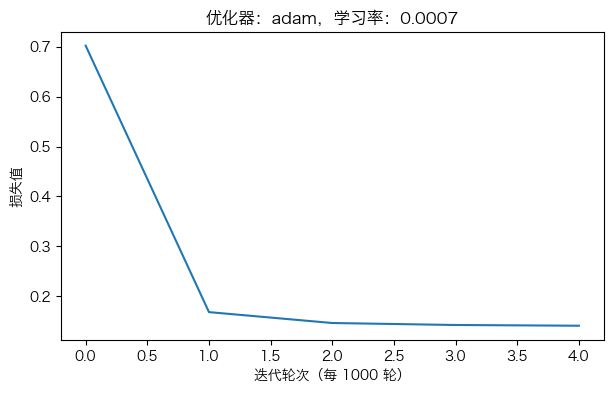


训练集准确率：
准确率：0.9333333333333333

决策边界（Adam + LR Decay）：


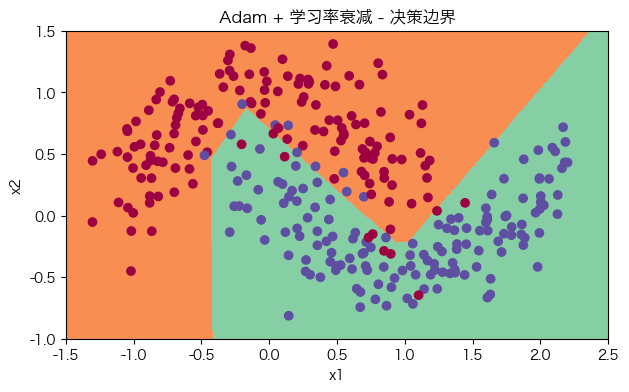

In [96]:
# 使用 Adam + 分段学习率衰减训练
parameters = model(train_X, train_Y, layers_dims, optimizer="adam",
                   learning_rate=0.0007, mini_batch_size=64,
                   beta1=0.9, beta2=0.999, epsilon=1e-8, num_epochs=5000,
                   print_cost=True, decay=schedule_lr_decay, decay_rate=1)
print("\n训练集准确率：")
predictions_train = predict(train_X, train_Y, parameters)
print("\n决策边界（Adam + LR Decay）：")
plt.title("Adam + 学习率衰减 - 决策边界")
axes = plt.gca()
axes.set_xlim([-1.5, 2.5])
axes.set_ylim([-1, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y[0,:])

<a name='8'></a>
## 8 - 总结 🎉

本实验以**植物病害检测**为应用场景，实现并比较了以下优化技术：

| 内容 | 关键公式 |
|------|---------|
| 梯度下降 | $W \leftarrow W - \alpha dW$ |
| 小批量梯度下降 | 随机打乱 → 分割 |
| 动量法 | $v_{dW} = \beta v_{dW} + (1-\beta)dW$，$W \leftarrow W - \alpha v_{dW}$ |
| Adam | 动量 + RMSProp + 偏差修正 |
| 指数学习率衰减 | $\alpha = \frac{\alpha_0}{1 + r \cdot t}$ |
| 分段学习率衰减 | 每 $T$ 轮更新一次 |

**核心结论**：
- Adam 在大多数场景下收敛**最快**，且对超参数不敏感
- 学习率衰减有助于在训练后期**精细调整**，避免在最优点附近震荡
- 选择合适的小批量大小（32~512）可以在计算效率和梯度质量间取得平衡

> 🌱 这些优化技术不仅适用于植物病害检测，在图像识别、自然语言处理等众多深度学习任务中都有广泛应用！